In [ ]:
pip install -r requirements.txt

In [1]:
import numpy as np
import torch
from torchvision import transforms
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from data_utils import AttributesDataset, ClassificationDataset, albumentation_transforms, compute_class_weights
from network.classification_net import MultiOutputModel
from solver import Solver
from vis_utils import visualize_grid

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, silhouette_score
from sklearn.manifold import TSNE
import seaborn as sns

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

%load_ext autoreload
%autoreload 2

## Get mean and Standard deviation of train dataset

In [2]:

data_folder_center = 'data/good_images_center'
data_folder_full = 'data/good_images'

attributes = AttributesDataset('data/all_data_new_clean1.csv')       
                           
to_tensor_trainset_full = transforms.Compose([transforms.ToTensor()]) # inputs are tensor with values between (0,1)
train_data = ClassificationDataset(data_folder_center, data_folder_full,'data/train_processed_new_clean1.csv',attributes,\
            to_tensor_center = to_tensor_trainset_full, to_tensor_full = to_tensor_trainset_full)

train_loader = torch.utils.data.DataLoader(train_data,
                                          batch_size=5,
                                          shuffle=False,
                                          num_workers=1)
nimages = 0
mean = 0.0                    
var = 0.0
for inputs in train_loader: #Note: inputs must be tensor with values between (0,1) - to calculate mean and std
    batch = inputs['img_full_crop']
    # Rearrange batch to be the shape of [B, C, W * H]
    batch = batch.view(batch.size(0), batch.size(1), -1)
    nimages += batch.size(0)
    # Compute mean and std here
    mean += batch.mean(2).sum(0) 
    var += batch.var(2).sum(0)
mean /= nimages
var /= nimages
std = torch.sqrt(var)
print(mean)
print(std)
print(nimages)

tensor([0.6872, 0.6295, 0.6625])
tensor([0.0891, 0.1300, 0.0741])
11528


Train size: 11528
Val size: 2379
Center cell Img size:  torch.Size([3, 120, 120])
Full crop Img size:  torch.Size([3, 120, 120])
Concatenated Img size:  torch.Size([6, 120, 120])
------------------------------------------------------------------------
Size classes:  ['MACR' 'MICR' 'NORM']
Shape classes:  ['ACAN' 'BITE' 'ECHI' 'ELLI' 'HELM' 'NONE' 'OVAL' 'SCHI' 'SICK' 'SPHE'
 'TEAR']
Hemoglobin distribution classes:  ['HYPO' 'HYPR' 'NONE' 'STOM' 'TARG']
Inclusion classes:  ['BAST', 'HOJO', 'MALA', 'NONE', 'NRBC', 'PABO', 'RETI']
------------------------------------------------------------------------


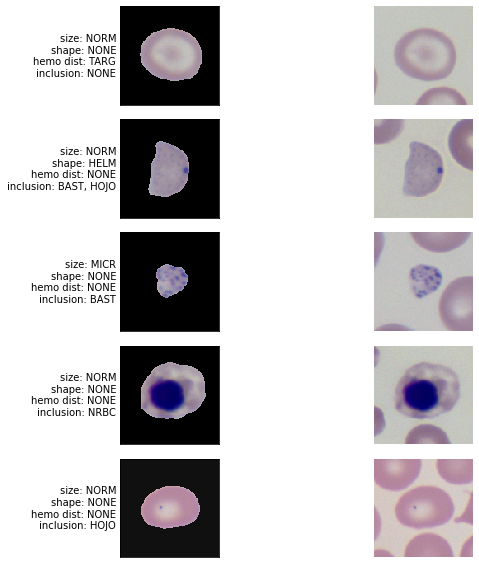

In [3]:
data_folder_center = 'data/good_images_center'
data_folder_full = 'data/good_images'

attributes = AttributesDataset('data/all_data_new_clean1.csv')

to_tensor_trainset_center = transforms.Compose([transforms.ToTensor()])
                             
to_tensor_trainset_full = transforms.Compose([transforms.ToTensor(),
                               transforms.Normalize((0.6872, 0.6295, 0.6625), (0.0891, 0.1300, 0.0741))])        

to_tensor_testset_center = transforms.Compose([transforms.ToTensor()])
                             
to_tensor_testset_full = transforms.Compose([transforms.ToTensor(),
                               transforms.Normalize((0.6869, 0.6237, 0.6573), (0.0812, 0.1271, 0.0747))])        

train_data = ClassificationDataset(data_folder_center, data_folder_full,'data/train_processed_new_clean1.csv',attributes,\
            to_tensor_center = to_tensor_trainset_center, to_tensor_full = to_tensor_trainset_full, aug_transforms = albumentation_transforms())

val_data = ClassificationDataset(data_folder_center, data_folder_full,'data/test_new_clean.csv', attributes, \
            to_tensor_center = to_tensor_testset_center, to_tensor_full = to_tensor_testset_full)

print("Train size: %i" % len(train_data))
print("Val size: %i" % len(val_data))
print("Center cell Img size: ", train_data[0]['img_center_cell'].size())
print("Full crop Img size: ", train_data[0]['img_full_crop'].size())
print("Concatenated Img size: ", train_data[0]['img'].size())
print('------------------------------------------------------------------------')

print("Size classes: ",attributes.size_labels)
print("Shape classes: ",attributes.shape_labels)
print("Hemoglobin distribution classes: ",attributes.hemo_dist_labels)
print("Inclusion classes: ",attributes.inclusion_labels)
print('------------------------------------------------------------------------')
# visualization.
num_example_imgs = 5
for i, dict_item in enumerate(train_data[0:num_example_imgs]):
    
    size_label = attributes.size_id_to_name[dict_item['labels']['size_label']]
    shape_label = attributes.shape_id_to_name[dict_item['labels']['shape_label']]
    hemo_dist_label = attributes.hemo_dist_id_to_name[dict_item['labels']['hemo_dist_label']]
    inclusion_label = np.array(attributes.inclusion_labels)[np.argwhere(dict_item['labels']['inclusion_label'] > 0)[:, 0]]
    label = "size: {}\nshape: {}\nhemo dist: {}\ninclusion: {}".format(size_label, shape_label, hemo_dist_label, ', '.join(inclusion_label))
 
    plt.subplot(num_example_imgs, 2, i * 2 + 1)
    img = dict_item['img_center_cell']
    plt.imshow(img.numpy().transpose(1,2,0))
    plt.xticks([])
    plt.yticks([])
    plt.ylabel(label, fontsize=10, rotation ='horizontal', ha ='right', va='center')
    
    plt.subplot(num_example_imgs, 2, i * 2 + 2)
    img = dict_item['img_full_crop']
    # unnormalize                              
    img[0] = img[0]*0.0891 + 0.6872
    img[1] = img[1]*0.1300 + 0.6295
    img[2] = img[2]*0.0741 + 0.6625
    plt.imshow(img.numpy().transpose(1,2,0))
    plt.axis('off')
plt.tight_layout()    
plt.show()

In [4]:
train_dataloader = torch.utils.data.DataLoader(train_data, batch_size=16, num_workers=1, shuffle=True)
                        
val_dataloader = torch.utils.data.DataLoader(val_data, batch_size=4, num_workers=1)

model = MultiOutputModel(size_classes = attributes.num_sizes, 
                         shape_classes = attributes.num_shapes, 
                         hemo_dist_classes = attributes.num_hemo_dist, 
                         inclusion_classes = attributes.num_inclusion).to(device)

size, shape, hemo, inc_ones, inc_zeros = compute_class_weights(train_data, attributes)

solver = Solver(size, shape, hemo, inc_ones, inc_zeros)   # arguments are class weights for each variation

Loaded pretrained weights for efficientnet-b7


Loaded pretrained weights for efficientnet-b7
START TRAIN.
Epoch  0  Train Loss  5.801722002724324 LR  0.0001  Val Loss  5.067288793200653
Epoch  1  Train Loss  3.6930774408111464 LR  0.0001  Val Loss  3.6229628007318753
Epoch  2  Train Loss  2.897727859921955 LR  0.0001  Val Loss  3.038785396177461
Epoch  3  Train Loss  2.4301762309527746 LR  0.0001  Val Loss  2.2626247921126286
Epoch  4  Train Loss  2.0173189055166834 LR  0.0001  Val Loss  1.9813201660967614
Epoch  5  Train Loss  1.7645820686173554 LR  0.0001  Val Loss  2.1407889475988813
Epoch  6  Train Loss  1.5613546861202496 LR  0.0001  Val Loss  1.8043324333522037
Epoch  7  Train Loss  1.4237678721495421 LR  0.0001  Val Loss  1.7396618760198341
Epoch  8  Train Loss  1.306770315441632 LR  0.0001  Val Loss  1.7007332843810181
Epoch  9  Train Loss  1.2770520363889744 LR  0.0001  Val Loss  1.7291203379230171
Epoch  10  Train Loss  1.1778646913110837 LR  0.0001  Val Loss  1.7312402415295618
Epoch  11  Train Loss  1.1210197513919171 L

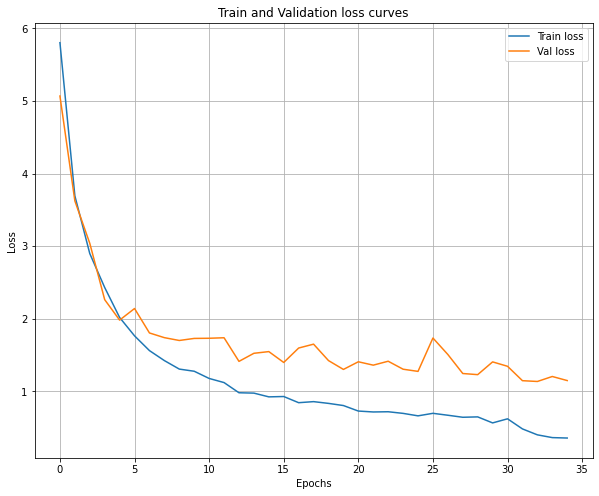

In [4]:
solver.train(model, train_dataloader, val_dataloader, num_epochs=35)  # training for merged type input

In [5]:
 model.save("models/merged_35_clean_steplr_simple_norm.model")

Saving model... models/merged_35_clean_hemo_net_steplr_simple_norm.model


In [6]:
model = torch.load("models/merged_35_clean_steplr_simple_norm.model")
model_predictions = solver.validate(model, val_dataloader)            # merged input type -  35 epochs steplr

------------------------------------------------------------------------
Validation  accuracy size: 0.9210, shape: 0.9307, hemo_dist: 0.8549, inclusion: 0.9794



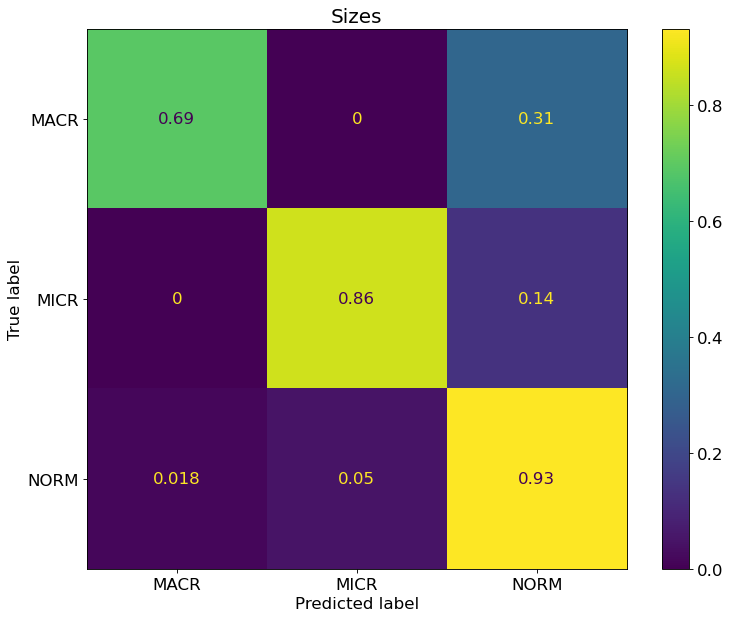

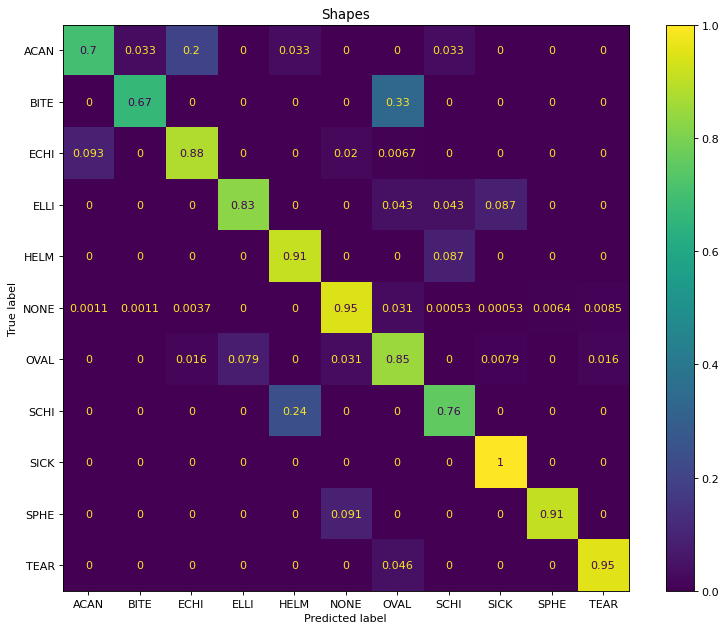

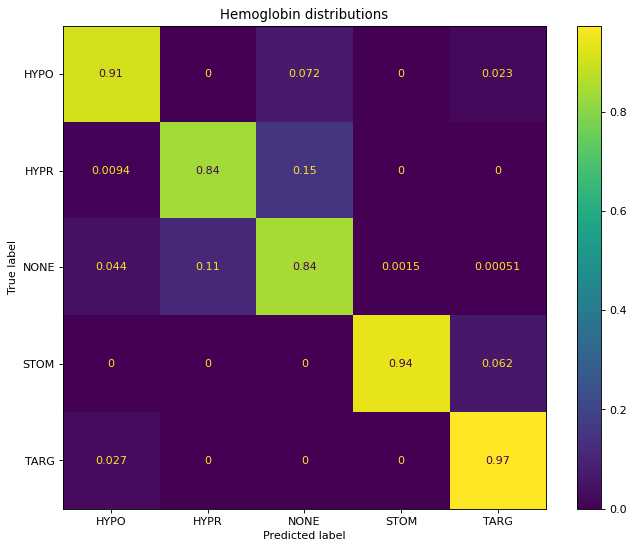

[[[2349    5]
  [   2   23]]

 [[2358    6]
  [   4   11]]

 [[2354    0]
  [   1   24]]

 [[ 117   10]
  [  13 2239]]

 [[2372    0]
  [   0    7]]

 [[2369    3]
  [   2    5]]

 [[2289   19]
  [  10   61]]]


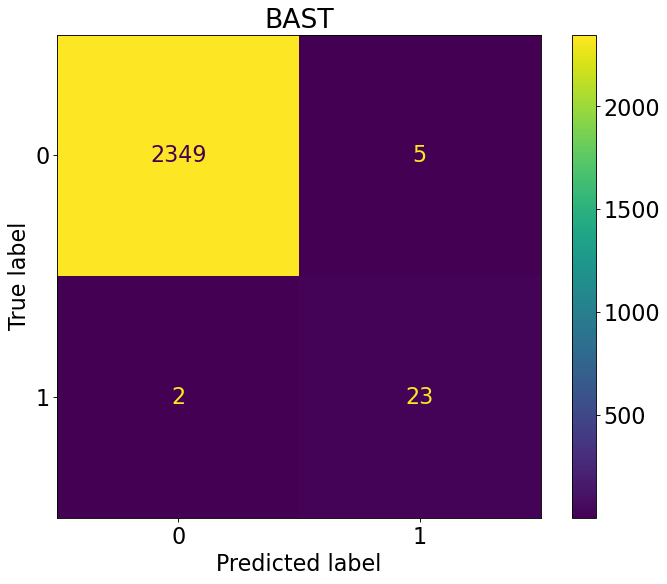

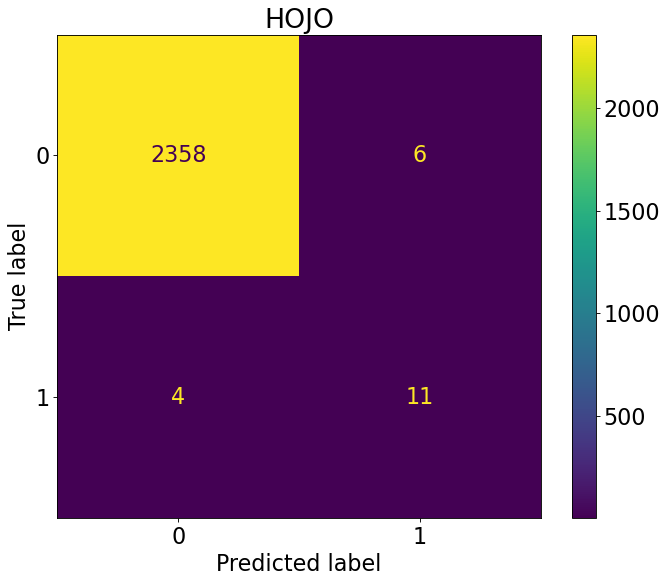

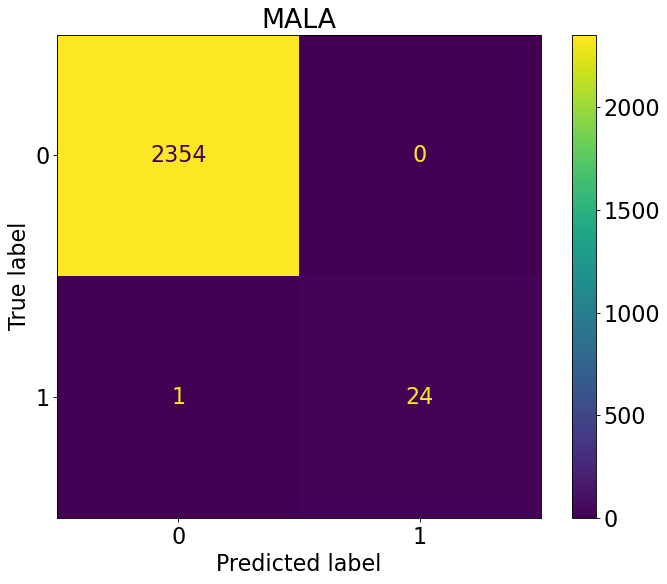

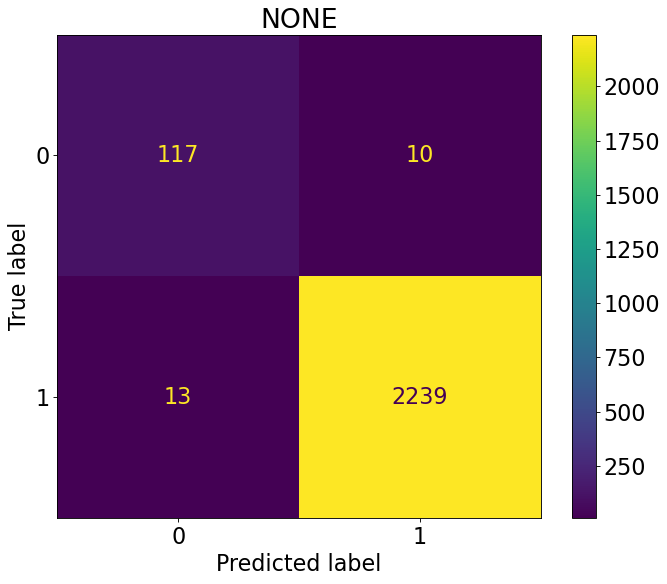

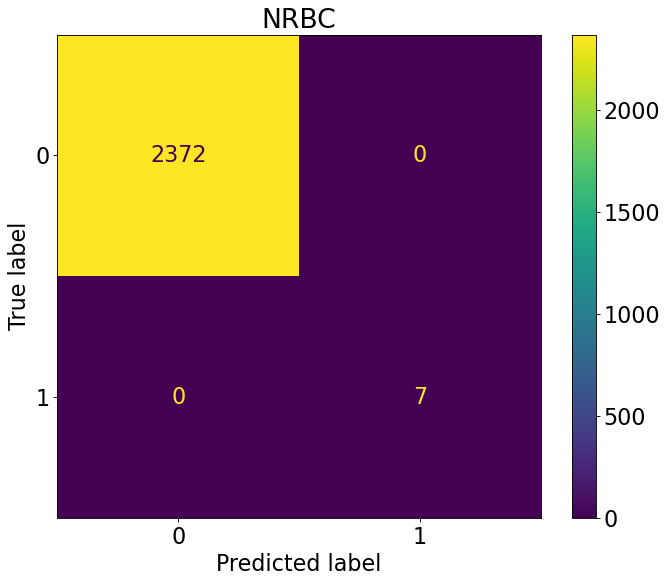

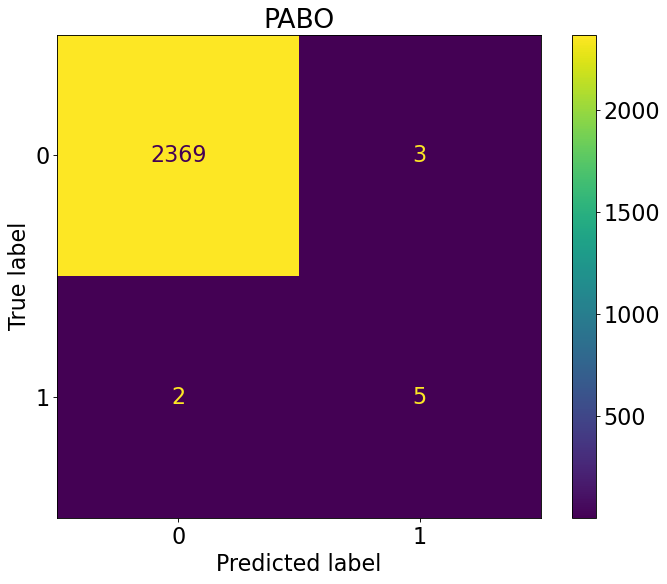

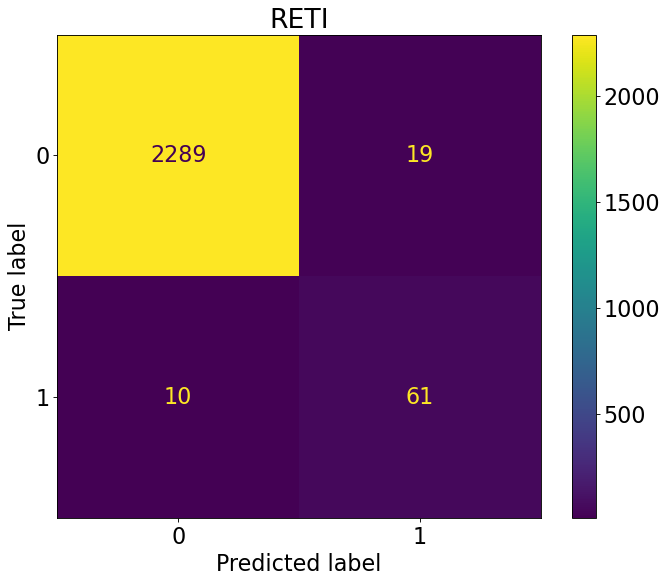

Metrics for Inclusions 
precision  [0.82142857 0.64705882 1.         0.99555358 1.         0.625
 0.7625    ]
recall  [0.92       0.73333333 0.96       0.99422735 1.         0.71428571
 0.85915493]
f1_score  [0.86792453 0.6875     0.97959184 0.99489002 1.         0.66666667
 0.80794702]


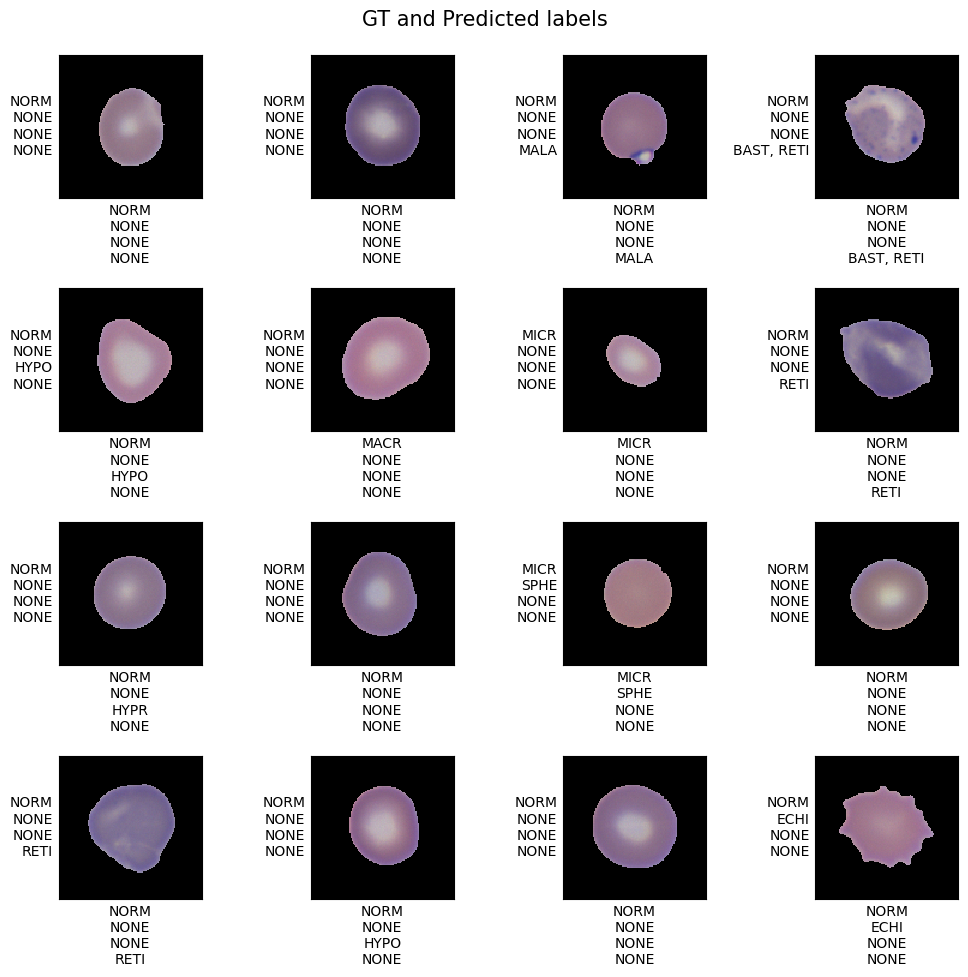

In [7]:
# Visualization results of the trained model
visualize_grid(val_data, attributes, *model_predictions)             # merged input type -  35 epochs steplr

#### Predictions from trained model using center cell input

In [11]:
model = torch.load("models/center_cell_clean_steplr_simple_norm.model")      #11528 training
model_predictions = solver.validate(model, val_dataloader)                # center cell input type, data in 0,1
                                                
    # Inside Validate, change batch['img'] to ['img_center_cell']
    # Also, check that the input channels of network are 3

------------------------------------------------------------------------
Validation  accuracy size: 0.9113, shape: 0.9251, hemo_dist: 0.8416, inclusion: 0.9761



### Visualization of deep learning features from Hemo dist. Classifier (center cell input)

In [21]:
predicted_vector = []
target_label_vector =[]
model.eval()
for batch in val_dataloader:
                img = batch['img_center_cell']
                target_labels = batch['labels']
                target_label_vector.extend(target_labels['hemo_dist_label']) 
                output = model(img.to(device))
                predicted_vector.extend(output['hemo_dist'].cpu().detach().numpy().tolist())
model.train() 
predicted_vector = np.array(predicted_vector)
predicted_vector.shape

(2379, 5)

In [22]:
X_input = predicted_vector
np.bincount(target_label_vector)

array([ 222,  106, 1960,   16,   75])

### Dimensionality reduction - PCA

[0.38208389 0.28901886]


<AxesSubplot:xlabel='pca1', ylabel='pca2'>

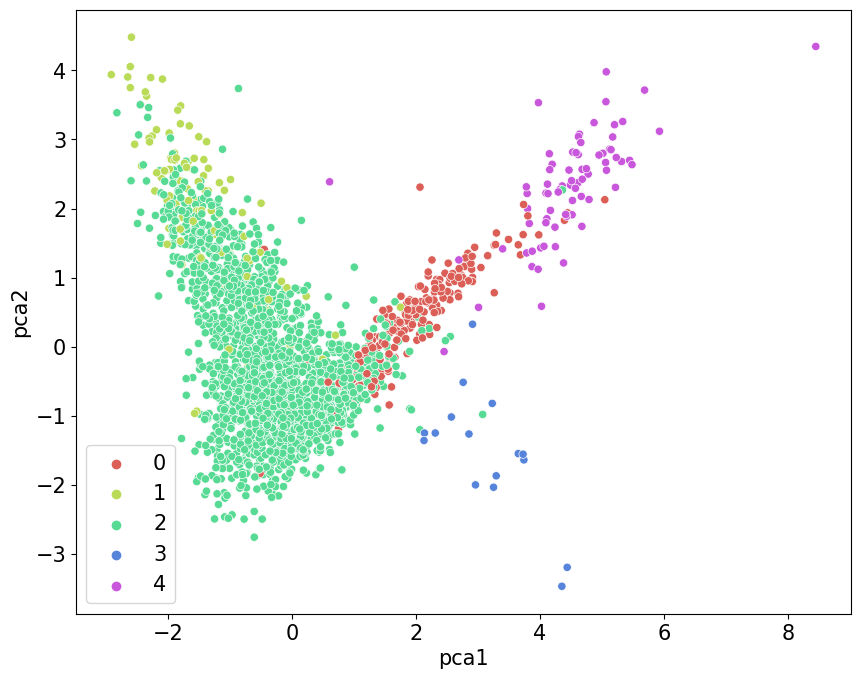

In [23]:
X = StandardScaler().fit_transform(X_input)   
pca = PCA(n_components=2) 
X_trans = pca.fit_transform(X)
print(pca.explained_variance_ratio_)

df_pca = pd.DataFrame(data = X_trans, columns = ['pca1','pca2'])
sns.scatterplot(x="pca1", y="pca2", hue=np.array(target_label_vector), data=df_pca, legend='full', palette=sns.color_palette("hls", 5))

### Dimensionality reduction  t-SNE

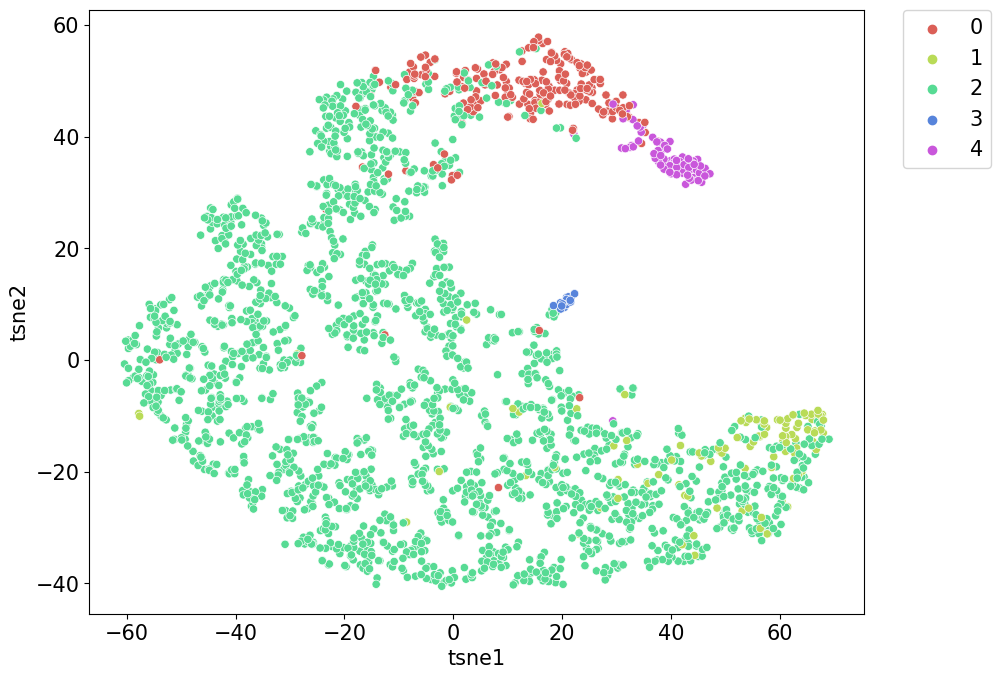

In [24]:
X = StandardScaler().fit_transform(X_input) 
X_tsne = TSNE(n_components=2,perplexity=30).fit_transform(X)

df_tsne = pd.DataFrame(data = X_tsne, columns = ['tsne1','tsne2'])

sns.scatterplot(x="tsne1", y="tsne2", hue=np.array(target_label_vector), data=df_tsne, palette=sns.color_palette("hls", 5))
plt.legend(bbox_to_anchor=(1.05,1),loc=2,borderaxespad=0.)